## NicheJepa Model training

Creator: Mohammad Vali Sanian (mohammad.sanian@helsinki.fi) (mv10@sanger.ac.uk).

Date of Creation: 16.08.2024

Date of Last Modification: 17.08.2024

# 1. Setup

## 1.1 Libraries 

In [1]:
import torch
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd
from tqdm import tqdm
import numpy as np
import scib_metrics
import scib
import scanpy as sc
import anndata as ad
import wandb
import logging
import os
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from src.nichejepa.train_sweep import train
from src.nichejepa.eval_sweep import evaluation
from src.nichejepa.utils.config_utils import create_params_from_YAML_wandb_config, prepare_dataset
from src.nichejepa.utils.distributed import init_distributed


/nfs/team361/mv10/.jepa/lib/python3.10/site-packages/dockerpycreds/utils.py:1: DeprecationWarning: The distutils package is deprecated and slated for removal in Python 3.12. Use setuptools or check PEP 632 for potential alternatives
  import distutils.spawn


## 1.2 Create params

In [2]:
rank=0
logging.basicConfig()
logger = logging.getLogger()
logger.setLevel(logging.INFO if rank == 0 else logging.ERROR)
params = create_params_from_YAML_wandb_config('configs/cnd_gtb10_ep300.yaml',logger)

INFO:root:Loaded parameters from YAML file.


## 1.3 Create Train,Test dataset

In [3]:
train_dataset, test_dataset = prepare_dataset(params)

# 2. Prepare Model Training

In [4]:
devices=['cuda:0']
world_size=1
os.environ['CUDA_VISIBLE_DEVICES'] = str(devices[rank].split(':')[-1])

logging.basicConfig()
logger = logging.getLogger()
logger.setLevel(logging.INFO if rank == 0 else logging.ERROR)

world_size, rank = init_distributed(rank_and_world_size=(rank, world_size), port=40316)
logger.info(f'Running... (rank: {rank}/{world_size})')
train(params, train_dataset, test_dataset)

INFO:root:Running... (rank: 0/1)
INFO:root:Initialized (rank/world-size) 0/1
INFO:root:GeneTransformerEncoder(
  (gene_embed): Embedding(1109, 768, padding_idx=0)
  (seg_embed): Embedding(3, 768, padding_idx=0)
  (blocks): ModuleList(
    (0-3): 4 x Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((768,), eps=1e-06, ele

/nfs/team361/mv10/.jepa/lib/python3.10/site-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 18 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


INFO:root:Initializing learning rate scheduler: WarmupCosineSchedule
INFO:root:Initializing weight decay scheduler: CosineWDSchedule
INFO:root:Initializing automatic mixed precision training scaler: GradScaler
INFO:root:Epoch 1


/nfs/team361/mv10/.jepa/lib/python3.10/site-packages/torch/utils/data/dataloader.py:558: UserWarning: This DataLoader will create 18 worker processes in total. Our suggested max number of worker in current system is 12, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(_create_warning_msg(


INFO:root:[1,     0] loss: 0.527 masks: 285.0 19.0 [wd: 4.00e-02] [lr: 5.00e-05] [mem: 9.40e+03] (723.7 ms)
INFO:root:[1,     0] grad_stats: [1.54e-01 1.16e-01] (3.40e-04, 1.83e-01)
INFO:root:[1,    10] loss: 0.329 masks: 285.0 19.0 [wd: 4.27e-02] [lr: 4.95e-05] [mem: 9.80e+03] (176.4 ms)
INFO:root:[1,    10] grad_stats: [4.75e-03 4.65e-03] (1.11e-05, 5.73e-03)
INFO:root:[1,    20] loss: 0.289 masks: 285.0 19.0 [wd: 4.97e-02] [lr: 4.90e-05] [mem: 9.80e+03] (150.3 ms)
INFO:root:[1,    20] grad_stats: [1.41e-03 1.26e-03] (3.46e-06, 1.69e-03)
INFO:root:[1,    30] loss: 0.272 masks: 285.0 19.0 [wd: 6.09e-02] [lr: 4.85e-05] [mem: 9.80e+03] (141.0 ms)
INFO:root:[1,    30] grad_stats: [6.81e-04 7.09e-04] (2.02e-06, 9.04e-04)
INFO:root:[1,    40] loss: 0.262 masks: 285.0 19.0 [wd: 7.61e-02] [lr: 4.80e-05] [mem: 9.80e+03] (136.3 ms)
INFO:root:[1,    40] grad_stats: [5.31e-04 5.23e-04] (1.64e-06, 6.55e-04)
INFO:root:[1,    50] loss: 0.256 masks: 285.0 19.0 [wd: 9.47e-02] [lr: 4.75e-05] [mem: 9.8

# 3. Analysis

## 3.1 Extract Features

In [5]:
adata = evaluation(params, train_dataset, test_dataset)

INFO:root:GeneTransformerEncoder(
  (gene_embed): Embedding(1109, 768, padding_idx=0)
  (seg_embed): Embedding(3, 768, padding_idx=0)
  (blocks): ModuleList(
    (0-3): 4 x Block(
      (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (attn): Attention(
        (qkv): Linear(in_features=768, out_features=2304, bias=True)
        (attn_drop): Dropout(p=0.0, inplace=False)
        (proj): Linear(in_features=768, out_features=768, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (drop_path): Identity()
      (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
      (mlp): MLP(
        (fc1): Linear(in_features=768, out_features=3072, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=3072, out_features=768, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
    )
  )
  (norm): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
)
INFO:root:loaded pretrained encoder from epoch 1 with

200it [00:11, 17.03it/s]
50it [00:03, 15.86it/s]
... storing 'split' as categorical
... storing 'label_name' as categorical
... storing 'cell_type' as categorical


AnnData has been successfully saved at: logs/Simulated_data_pred_depth_3_pred_emb_dim_768_enc_depth_4_n_targets_4_n_contexts_1_target_mask_size_19_context_mask_size_361_num_epochs_1/extracted_features/cell_embedding_average.h5ad


## 3.2 Feature Analysis

In [6]:
similarity_matrix = cosine_similarity(adata.obsm['jepa_emb'])
similarity_matrix

array([[1.        , 0.9969258 , 0.9969901 , ..., 0.99674374, 0.99699247,
        0.99725133],
       [0.9969258 , 0.99999976, 0.99748063, ..., 0.9971765 , 0.9971946 ,
        0.99743235],
       [0.9969901 , 0.99748063, 0.99999976, ..., 0.99662435, 0.9971414 ,
        0.9972323 ],
       ...,
       [0.99674374, 0.9971765 , 0.99662435, ..., 0.9999999 , 0.9971962 ,
        0.9969304 ],
       [0.99699247, 0.9971946 , 0.9971414 , ..., 0.9971962 , 0.99999976,
        0.99724996],
       [0.99725133, 0.99743235, 0.9972323 , ..., 0.9969304 , 0.99724996,
        1.        ]], dtype=float32)

## 3.3 Umap

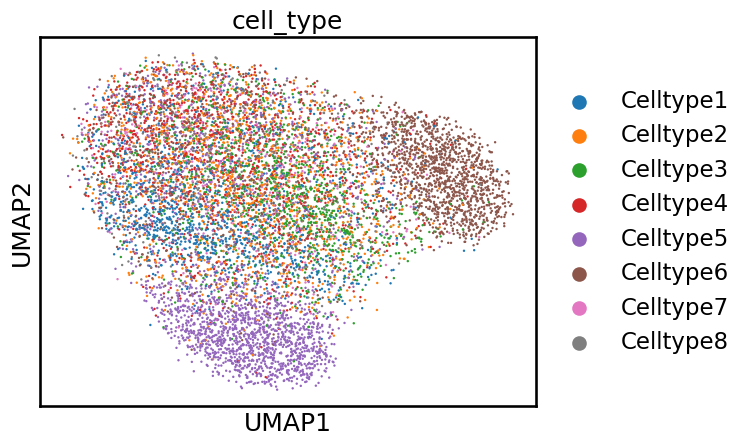

In [7]:
sc.pp.neighbors(adata, n_neighbors=10, use_rep='jepa_emb')
sc.tl.umap(adata)

# Plot the UMAP
sc.pl.umap(adata, color='cell_type')

## 3.4 Logistic regression

In [18]:

# Extract features and labels
X = adata.obsm['jepa_emb']
y = adata.obs['cell_type']  # Replace 'cell_type' with any categorical annotation in adata.obs

# Use the 'split' column to create training and testing sets
train_mask = adata.obs['split'] == 'train'
test_mask = adata.obs['split'] == 'test'

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

# Initialize Logistic Regression 
clf = LogisticRegression()  
# Train the classifier
clf.fit(X_train, y_train)

# Predict on the test set
y_test_pred = clf.predict(X_test)

# Evaluate the model on the test set
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
print(f"Test Accuracy: {test_accuracy:.2f}")
print(f"Test F1 Score: {test_f1:.2f}")

# Predict on the training set
y_train_pred = clf.predict(X_train)

# Evaluate the model on the training set
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='weighted')
print(f"Train Accuracy: {train_accuracy:.2f}")
print(f"Train F1 Score: {train_f1:.2f}")

Test Accuracy: 0.76
Test F1 Score: 0.75
Train Accuracy: 0.81
Train F1 Score: 0.81


/nfs/team361/mv10/.jepa/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 3.5 KNeighborsClassifier

In [23]:
# Extract features and labels
X = adata.obsm['jepa_emb']
y = adata.obs['cell_type']  # Replace 'cell_type' with any categorical annotation in adata.obs

# Use the 'split' column to create training and testing sets
train_mask = adata.obs['split'] == 'train'
test_mask = adata.obs['split'] == 'test'

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

# Initialize Logistic Regression 
clf = KNeighborsClassifier(n_neighbors=5)
# Train the classifier
clf.fit(X_train, y_train)

# Predict on the test set
y_test_pred = clf.predict(X_test)

# Evaluate the model on the test set
test_accuracy = accuracy_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred, average='weighted')
print(f"Test Accuracy: {test_accuracy:.2f}")
print(f"Test F1 Score: {test_f1:.2f}")

# Predict on the training set
y_train_pred = clf.predict(X_train)

# Evaluate the model on the training set
train_accuracy = accuracy_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred, average='weighted')
print(f"Train Accuracy: {train_accuracy:.2f}")
print(f"Train F1 Score: {train_f1:.2f}")

Test Accuracy: 0.51
Test F1 Score: 0.48
Train Accuracy: 0.66
Train F1 Score: 0.64


## 3.6 nmi&ari

In [21]:
result = scib_metrics.nmi_ari_cluster_labels_kmeans(adata.obsm['jepa_emb'], adata.obs['cell_type'])

INFO:jax._src.xla_bridge:Unable to initialize backend 'cuda': 
INFO:jax._src.xla_bridge:Unable to initialize backend 'rocm': module 'jaxlib.xla_extension' has no attribute 'GpuAllocatorConfig'
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


/nfs/team361/mv10/.jepa/lib/python3.10/site-packages/jax/_src/linear_util.py:192: DeprecationWarning: Passing arguments 'a', 'a_min', or 'a_max' to jax.numpy.clip is deprecated. Please use 'x', 'min', and 'max' respectively instead.
  ans = self.f(*args, **dict(self.params, **kwargs))


In [22]:
result

{'nmi': 0.3077322675603466, 'ari': 0.267855332706911}